# Bass Model Homework: Claude Sonnet 4

## 1. Chosen Innovation

The innovation selected for this analysis is **Claude Sonnet 4**, a general-purpose
large language model developed by Anthropic and featured in TIME's Best Inventions
of 2025: https://time.com/collections/best-inventions-2025/7318244/anthropic-claude-sonnet-4/

Claude Sonnet 4 was released in May 2025 and saw rapid adoption: according to
Anthropic, 75% of its API users switched to the new model within a week of
release. It became especially popular among developers, and after release its
context window was expanded so it could process much longer inputs, such as large
codebases. Anthropic followed it with Claude Sonnet 4.5 in September 2025 [1].

## 2. Look-alike Innovation: The Internet

The Internet is selected as the look-alike innovation for Claude Sonnet 4. Both are
general-purpose information technologies rather than single-function products:
people use them to search for information, communicate, write, learn, and work.
Like the Internet, large language models are accessed through devices that users
already own, such as computers and smartphones, so adoption is limited mainly by
awareness, perceived usefulness, and learning, not by the cost of new hardware.

The two innovations also share the same diffusion mechanism. In both cases a small
group of technical early adopters is followed by mass adoption driven by word of
mouth and social influence, which corresponds directly to the coefficients of
innovation (p) and imitation (q) in the Bass model [2]. Finally, both target the
general population worldwide, and adoption can be measured in the same way: as the
share of individuals using the technology. Internet adoption has been recorded
annually by the International Telecommunication Union (ITU) for more than three
decades [3], providing a complete S-shaped diffusion curve on which the Bass model
parameters can be estimated.



## 3. Historical Data

The data for the look-alike innovation is the annual share of the population using
the Internet, collected by the International Telecommunication Union (ITU) and
published by Our World in Data [3]. The dataset covers individual countries,
regions, and the world as a whole from 1990 onward. The analysis below uses the
US series; the choice of scope is discussed in Sections 3.1 and 6.

Source file: `data/share-of-individuals-using-the-internet.csv`

In [5]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/share-of-individuals-using-the-internet.csv")
df.columns = ["entity", "code", "year", "share_pct"]

world = df[df["entity"] == "World"][["year", "share_pct"]].reset_index(drop=True)
display(world)

,year,share_pct
0,2005,15.6
1,2006,17.2
2,2007,20.2
3,2008,22.8
4,2009,25.3
5,2010,28.4
6,2011,30.9
7,2012,33.3
8,2013,35.3
9,2014,37.4


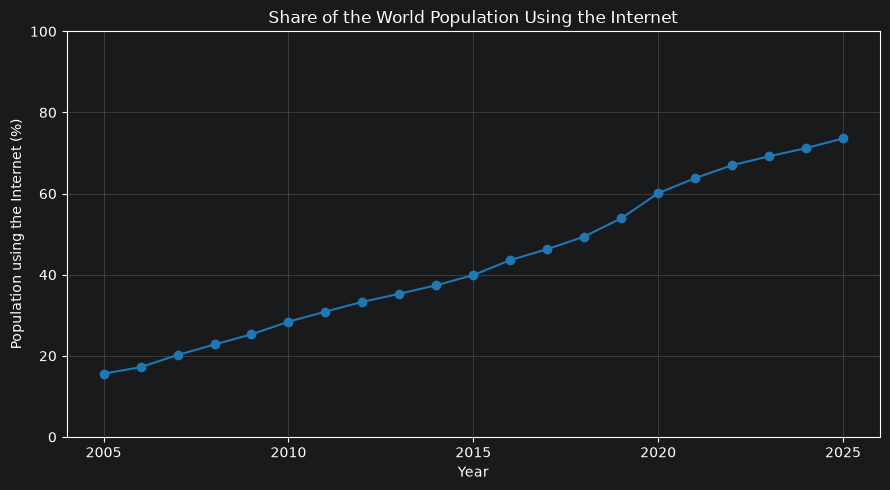

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(world["year"], world["share_pct"], marker="o", color="tab:blue")
ax.set_title("Share of the World Population Using the Internet")
ax.set_xlabel("Year")
ax.set_ylabel("Population using the Internet (%)")
ax.set_ylim(0, 100)
ax.set_xticks(range(2005, world["year"].max() + 1, 5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../img/internet_adoption_world.png", dpi=150)
plt.show()

Let's see the historical dataset description.

In [8]:
# Overview of the full dataset
print("Full dataset")
print(f"  Rows: {len(df)}")
print(f"  Entities (countries and regions): {df['entity'].nunique()}")
print(f"  Years covered: {df['year'].min()}–{df['year'].max()}")
print(f"  Missing values: {df['share_pct'].isna().sum()}")

# Overview of the worldwide series used in the analysis
expected_years = set(range(world["year"].min(), world["year"].max() + 1))
missing_years = sorted(expected_years - set(world["year"]))

print("\nWorldwide series")
print(f"  Years covered: {world['year'].min()}–{world['year'].max()} ({len(world)} observations)")
print(f"  Missing years: {missing_years if missing_years else 'none'}")
print(f"  First value: {world['share_pct'].iloc[0]:.2f}% ({world['year'].iloc[0]})")
print(f"  Last value: {world['share_pct'].iloc[-1]:.2f}% ({world['year'].iloc[-1]})")

# Yearly increase in adoption (percentage points)
world["yearly_increase_pp"] = world["share_pct"].diff()
peak = world.loc[world["yearly_increase_pp"].idxmax()]
print(f"  Largest yearly increase: {peak['yearly_increase_pp']:.2f} pp in {int(peak['year'])}")

display(world["share_pct"].describe().round(2).to_frame("share_pct (%)"))

Full dataset
  Rows: 6659
  Entities (countries and regions): 231
  Years covered: 1990–2025
  Missing values: 0

Worldwide series
  Years covered: 2005–2025 (21 observations)
  Missing years: none
  First value: 15.60% (2005)
  Last value: 73.60% (2025)
  Largest yearly increase: 6.20 pp in 2020


,share_pct (%)
count,21.00
mean,43.07
std,18.84
min,15.60
25%,28.40
50%,39.90
75%,60.10
max,73.60


In [9]:
for country in ["United States", "Armenia"]:
    s = df[df["entity"] == country][["year", "share_pct"]]
    expected = set(range(s["year"].min(), s["year"].max() + 1))
    print(f"{country}: {s['year'].min()}–{s['year'].max()}, "
          f"{len(s)} observations, missing years: {sorted(expected - set(s['year']))}")
    print(f"  {s['share_pct'].iloc[0]:.2f}% → {s['share_pct'].iloc[-1]:.2f}%\n")

United States: 1990–2024, 35 observations, missing years: []
  0.79% → 94.69%

Armenia: 1990–2024, 32 observations, missing years: [1991, 1992, 1993]
  0.00% → 81.34%



### 3.1 Data Overview

The dataset contains 6,659 annual observations for 231 countries and regions
(1990–2025), with no missing values. The worldwide series covers 2005–2025: adoption
grew from 15.6% to 73.6%, with the largest yearly increase (6.2 pp) in 2020, likely
driven by the COVID-19 pandemic. However, this series starts when 15.6% of the
world was already online, so it misses the early diffusion phase that the Bass
model relies on to estimate p. The analysis therefore uses the United States series,
which is complete from 1990 to 2024 (0.79% → 94.69%, no missing years).

## 4. Estimating the Bass Model Parameters

In [10]:
import sys
sys.path.append("..")
from helper_functions import bass_F, bass_cumulative, fit_bass, r_squared, peak_time
import numpy as np

The Bass model [2] describes cumulative adoption as $A(t) = M \cdot F(t)$, where

$$F(t) = \frac{1 - e^{-(p+q)t}}{1 + \frac{q}{p} e^{-(p+q)t}}$$

$p$ is the coefficient of innovation, $q$ is the coefficient of imitation, and $M$
is the market potential. The parameters are estimated by non-linear least squares
on the US cumulative adoption series, with $t = 1$ in 1990. $M$ is expressed as a
share of the population and is bounded by 100%.

In [11]:
us = df[df["entity"] == "United States"][["year", "share_pct"]].reset_index(drop=True)
launch_year = us["year"].min()
t = us["year"] - launch_year + 1

p, q, m = fit_bass(t, us["share_pct"], m_upper=100)
us["fitted_pct"] = bass_cumulative(t, p, q, m)
r2 = r_squared(us["share_pct"], us["fitted_pct"])
t_peak = peak_time(p, q)

results = pd.DataFrame({
    "Parameter": ["p (innovation)", "q (imitation)",
                  "M (market potential, % of population)", "R²", "Peak adoption year"],
    "Value": [round(p, 4), round(q, 4), round(m, 2), round(r2, 4),
              round(launch_year - 1 + t_peak, 1)],
})
display(results)

,Parameter,Value
0,p (innovation),0.0248
1,q (imitation),0.1321
2,"M (market potential, % of population)",94.6900
3,R²,0.9614
4,Peak adoption year,1999.7000


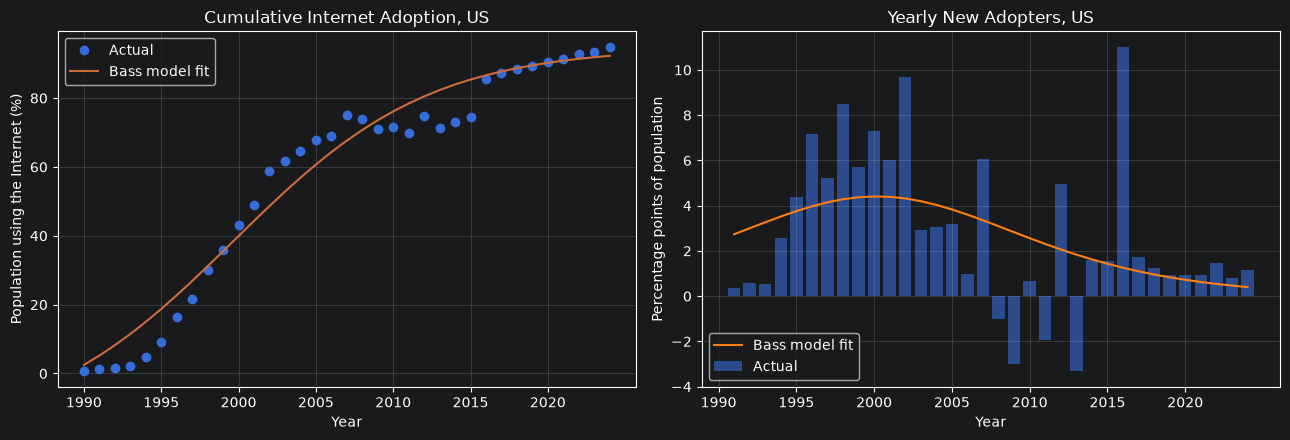

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(us["year"], us["share_pct"], "o", label="Actual")
axes[0].plot(us["year"], us["fitted_pct"], "-", label="Bass model fit")
axes[0].set_title("Cumulative Internet Adoption, US")
axes[0].set_ylabel("Population using the Internet (%)")

axes[1].bar(us["year"], us["share_pct"].diff(), alpha=0.6, label="Actual")
axes[1].plot(us["year"], us["fitted_pct"].diff(), "-", color="tab:orange", label="Bass model fit")
axes[1].set_title("Yearly New Adopters, US")
axes[1].set_ylabel("Percentage points of population")

for ax in axes:
    ax.set_xlabel("Year")
    ax.set_xticks(range(1990, 2025, 5))
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("../img/bass_fit_internet_us.png", dpi=150)
plt.show()

The model fits the data well (R² = 0.96): it captures the overall S-shape of
Internet adoption in the US, with yearly adoption peaking around 2000. The
coefficient of imitation is about five times larger than the coefficient of
innovation, which means adoption was driven mainly by word of mouth
and social influence rather than by independent early adopters. Compared with the
average values reported in a meta-analysis of diffusion studies, the Internet shows a similar innovation effect but a slower
imitation effect, which spreads adoption over a longer period.

The estimated market potential M equals the latest observed value (94.69%), which
indicates that Internet adoption in the US has practically reached saturation.

The fit is less accurate in some periods. The model overestimates adoption in
1990–1996, when the Internet spread more slowly than the model predicts, and
underestimates it around 2000–2008. The actual series also shows a plateau with
small declines in 2008–2015 and a sharp increase in 2016. Since people rarely stop
using the Internet, these irregularities most likely reflect changes in how
Internet use was measured, not real changes in adoption.

## 5. Predicting the Diffusion of Claude Sonnet 4

Assuming that Claude Sonnet 4 diffuses in the same way as its look-alike, the
coefficients estimated for the Internet are applied
to Claude Sonnet 4, with $t = 1$ in 2025, its year of release [1]. The forecast
shows the share of the market potential $M$ that adopts each year, and the
cumulative share $F(t)$. The size of $M$ for Claude Sonnet 4 is estimated in
Sections 6–7.

In [13]:
claude_launch = 2025
forecast_years = np.arange(claude_launch, claude_launch + 26)
t_f = forecast_years - claude_launch + 1

forecast = pd.DataFrame({
    "year": forecast_years,
    "new_adopters_pct_of_M": (bass_F(t_f, p, q) - bass_F(t_f - 1, p, q)) * 100,
    "cumulative_pct_of_M": bass_F(t_f, p, q) * 100,
})
display(forecast.round(2))

peak_year = claude_launch - 1 + t_peak
half_year = forecast.loc[forecast["cumulative_pct_of_M"] >= 50, "year"].iloc[0]
print(f"Predicted peak of yearly adoption: {peak_year:.1f}")
print(f"Half of the market potential reached by: {half_year}")

,year,new_adopters_pct_of_M,cumulative_pct_of_M
0,2025,2.61,2.61
1,2026,2.89,5.50
2,2027,3.17,8.67
3,2028,3.45,12.12
4,2029,3.72,15.83
5,2030,3.97,19.80
6,2031,4.19,23.99
7,2032,4.38,28.37
8,2033,4.52,32.89
9,2034,4.62,37.51


Predicted peak of yearly adoption: 2034.7
Half of the market potential reached by: 2037


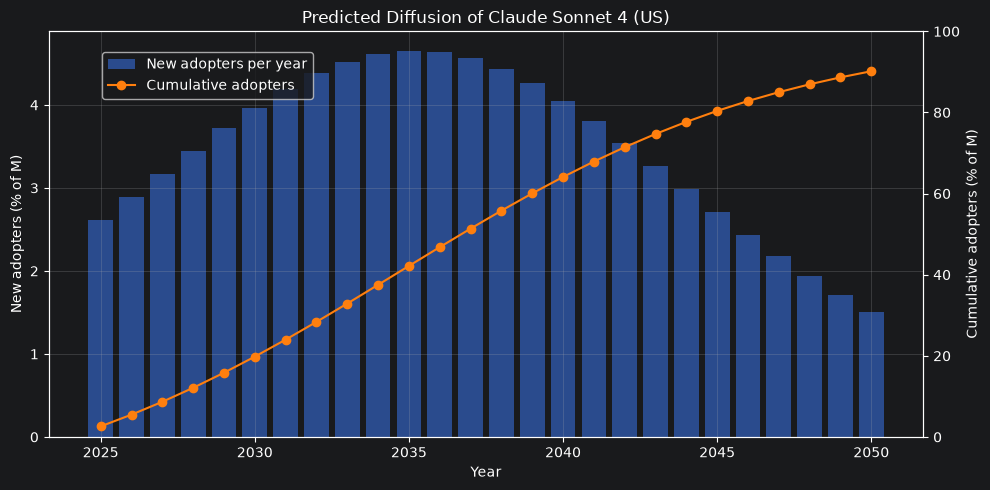

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(forecast["year"], forecast["new_adopters_pct_of_M"], alpha=0.6, label="New adopters per year")
ax1.set_ylabel("New adopters (% of M)")

ax2 = ax1.twinx()
ax2.plot(forecast["year"], forecast["cumulative_pct_of_M"], "o-", color="tab:orange", label="Cumulative adopters")
ax2.set_ylabel("Cumulative adopters (% of M)")
ax2.set_ylim(0, 100)

ax1.set_title("Predicted Diffusion of Claude Sonnet 4 (US)")
ax1.set_xlabel("Year")
ax1.set_xticks(forecast["year"][::5])
ax1.grid(alpha=0.3)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig("../img/claude_diffusion_forecast.png", dpi=150)
plt.show()

### 5.1 Results

Although Claude Sonnet 4 is already on the market, its adoption history is too
short to estimate the Bass parameters directly. The parameters of its look-alike,
the Internet, are therefore used to forecast its diffusion.

As shown in the forecast table and figure above, the predicted adoption follows
the typical S-shaped curve: 2.61% of the market potential adopts in 2025, and
cumulative adoption reaches 19.80% of M by 2030. Yearly adoption peaks around
2035 (4.65% of M), after which it gradually declines as the market approaches
saturation. The low coefficient of imitation (q = 0.1321) results in a long
diffusion period, so this forecast can be seen as a conservative scenario.

## 6. Scope: United States

The analysis focuses on the United States rather than the whole world, for three
reasons.

First, the US is Claude's largest market. According to the Anthropic Economic
Index, the United States accounts for 21.6% of global Claude.ai usage, the
highest share of any country, ahead of India, Brazil, Japan and South Korea [4].
Anthropic is also a US-based company, so the US is its home and primary market.

Second, the data supports a country-level analysis. As shown in Section 3, the
US Internet adoption series is complete for 1990–2024, while the worldwide
series starts only in 2005 and misses the early diffusion phase.

Third, a single country gives a well-defined market. Its population is known, so
the market potential can be translated into a number of adopters (Section 7),
and the look-alike and the forecast refer to the same population.

## 7. Number of Adopters by Period

I found out that the market potential $M$ is estimated using Fermi logic. The US population was
341,784,857 on July 1, 2025, of which 21.1% were under 18 [5]. Since 44% of US
adults use ChatGPT [6], this share is used as a proxy for adults who use AI
assistants and could therefore adopt Claude. The number of new adopters in year
$t$ is $a(t) = M \cdot (F(t) - F(t-1))$.

In [15]:
us_population = 341_784_857
share_adults = 1 - 0.211
share_ai_users = 0.44

M_claude = us_population * share_adults * share_ai_users
print(f"Market potential M: {M_claude / 1e6:.1f} million adults")

forecast["new_adopters_mln"] = M_claude * forecast["new_adopters_pct_of_M"] / 100 / 1e6
forecast["cumulative_adopters_mln"] = M_claude * forecast["cumulative_pct_of_M"] / 100 / 1e6
display(forecast[["year", "new_adopters_mln", "cumulative_adopters_mln"]].round(2))

Market potential M: 118.7 million adults


,year,new_adopters_mln,cumulative_adopters_mln
0,2025,3.10,3.10
1,2026,3.43,6.53
2,2027,3.76,10.29
3,2028,4.09,14.38
4,2029,4.41,18.79
5,2030,4.71,23.49
6,2031,4.97,28.47
7,2032,5.20,33.66
8,2033,5.37,39.03
9,2034,5.48,44.51


The estimated market potential is 118.7 million US adults. The model predicts
that 3.10 million adults start using Claude in 2025, and about 23.5 million in
total by 2030. The number of new users grows every year until 2035, when it
peaks at 5.52 million, and by then about half of the market potential
(50.03 million people) has adopted Claude. After 2035, yearly adoption slowly
declines as fewer potential users remain.

## Conclusion

Using the Internet as a look-alike innovation, the Bass model was estimated on US
Internet adoption data (p = 0.0248, q = 0.1321, R² = 0.96) and applied to Claude.
With a market potential of 118.7 million US adults, the forecast shows adoption
growing steadily from 3.10 million new users in 2025 to a peak of 5.52 million in
2035. Since adoption is driven mainly by imitation (q > p), word of mouth and
social influence are expected to be the main drivers of Claude's growth.

## References

[1] Hays, K. (2025, October 9). Anthropic Claude Sonnet 4. *TIME Best Inventions
2025*. https://time.com/collections/best-inventions-2025/7318244/anthropic-claude-sonnet-4/

[2] Bass, F. M. (1969). A new product growth for model consumer durables.
*Management Science*, 15(5), 215–227.

[3] International Telecommunication Union (ITU), via Our World in Data. (2025).
Share of the population using the Internet [Data set].
https://ourworldindata.org/grapher/share-of-individuals-using-the-internet

[4] Anthropic. (2025, September 15). Anthropic Economic Index: Tracking AI's role
in the US and global economy. https://www.anthropic.com/research/economic-index-geography

[5] U.S. Census Bureau. (2025). QuickFacts: United States (V2025).
https://www.census.gov/quickfacts/fact/table/US

[6] Pew Research Center. (2026, June 17). Americans and AI 2026: Chatbots, Smart
Devices and Views on Impact. https://www.pewresearch.org/internet/2026/06/17/americans-and-ai-appendix-detailed-chart-and-tables/